In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

## VERİ YÜKLEME & ÖN İŞLEME

In [8]:
df = pd.read_csv("data/train.csv")

In [9]:
df.drop(columns=["PassengerId","Name","Ticket"],inplace=True)
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})
df["Cabin"] = df["Cabin"].notnull().astype(int)
df["Embarked"] = df["Embarked"].fillna(0)
df["Age"] = df["Age"].fillna(df["Age"].median())

In [10]:
features = ["Pclass","Sex","Age","SibSp","Parch","Fare","Cabin","Embarked"]

X = df[features]
y = df["Survived"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test  seti : {X_test.shape[0]} örnek\n")

Eğitim seti: 712 örnek
Test  seti : 179 örnek



## MODELİ EĞİT

- n_estimators  → kaç tane ağaç? (100 iyi bir başlangıç)
- max_depth     → her ağacın max derinliği
- max_features  → her bölünmede kaç özellik denensin?

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    max_features="sqrt",   # klasik RF standardı
    random_state=42
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

## TAHMİN & DEĞERLENDİRME

In [14]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(confusion_matrix(y_test,y_pred))
print(f"Test Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Hayatta Kalmadı", "Hayatta Kaldı"]))

[[92 13]
 [23 51]]
Test Accuracy: 0.7989

Classification Report:
                 precision    recall  f1-score   support

Hayatta Kalmadı       0.80      0.88      0.84       105
  Hayatta Kaldı       0.80      0.69      0.74        74

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



## KARMAŞIKLIK MATRİSİ

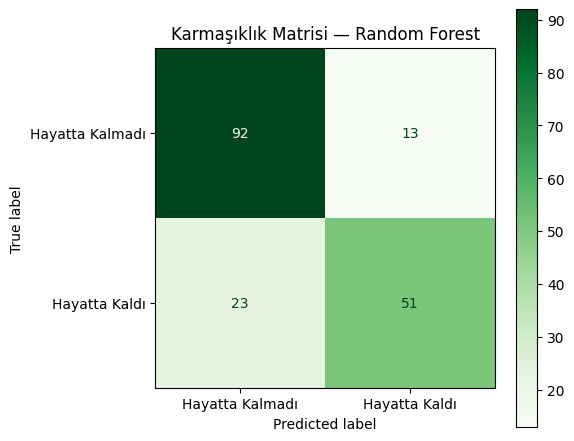

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Hayatta Kalmadı", "Hayatta Kaldı"],
    cmap="Greens", ax=ax
)
ax.set_title("Karmaşıklık Matrisi — Random Forest")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150)
plt.show()

## ÖZELLİK ÖNEMİ

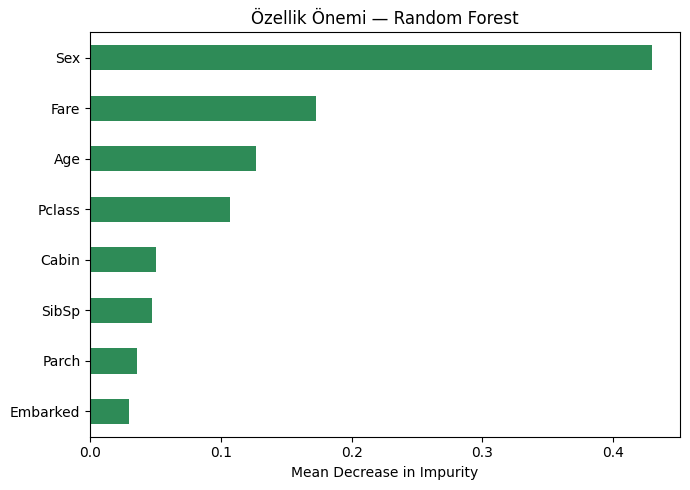

Özellik Önemleri (büyükten küçüğe):
Sex         0.429701
Fare        0.173043
Age         0.127045
Pclass      0.106876
Cabin       0.050634
SibSp       0.047297
Parch       0.035611
Embarked    0.029793


In [16]:
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", color="seagreen", ax=ax)
ax.set_title("Özellik Önemi — Random Forest")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

print("Özellik Önemleri (büyükten küçüğe):")
print(importances.sort_values(ascending=False).to_string())

## OVERFITTING KONTROLÜ

In [17]:
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"\nTrain Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Fark           : {train_acc - test_acc:.4f}")


Train Accuracy : 0.8694
Test  Accuracy : 0.7989
Fark           : 0.0705


In [20]:
from sklearn.model_selection import cross_val_score
 
# Cross-Validation (5-Fold)
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
 
print(f"5-Fold CV Accuracy Skorları : {cv_scores_rf.round(4)}")
print(f"Ortalama                    : {cv_scores_rf.mean():.4f}")
print(f"Std Dev                     : {cv_scores_rf.std():.4f}")

5-Fold CV Accuracy Skorları : [0.7933 0.8258 0.8483 0.7921 0.8708]
Ortalama                    : 0.8261
Std Dev                     : 0.0307
